# 18-Diagnostics & Learning Curves

In our previous 17 lessons, we have assembled a state-of-the-art Deep Learning engine. We architected the network, initialized the weights, stabilized the gradients, scheduled the learning rates, and balanced the data.

You press "Run" on your PyTorch training loop. The GPU fans spin up. Numbers start scrolling across your terminal.

...But is it actually working?

If a network outputs a Loss of $2.4$, is that good? If it drops to $1.2$, is the network ready for production? Training a Deep Neural Network without diagnostics is like flying a Boeing 747 in a thunderstorm with no instruments. In this lesson, we will learn how to read the telemetry of our network to diagnose catastrophic failures, capacity limits, and memorization traps.

The absolute most important diagnostic tool in Deep Learning is the **Learning Curve**. It is a simple 2D line chart that plots the passage of time (Epochs) on the X-axis against the mathematical error (Loss) on the Y-axis.

To properly diagnose a network, you must plot *two* lines simultaneously: the **Training Loss** and the **Validation Loss**. The gap between these two lines tells you exactly what is wrong with your architecture.

Let's set up our PyTorch environment to read the matrix.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Deep Learning Diagnostics Environment Ready.")

✅ Deep Learning Diagnostics Environment Ready.


# 1. Underfitting (The Capacity Problem)

**Symptom:** Both the Training Loss and Validation Loss remain incredibly high and flatline early. They do not drop to zero.

**The Diagnosis:** The network is mathematically too weak to understand the data. This is an architecture problem. You are trying to predict highly complex, non-linear reality (like human speech or self-driving car vision) using a network that only has 1 or 2 shallow layers. The model simply lacks the necessary "neurons" to draw the complex mathematical boundaries required.

**The Enterprise Prescription:**

1. **Increase Model Capacity:** Add more hidden layers (go deeper) or add more neurons to existing layers (go wider).
2. **Decrease Regularization:** If you have Dropout set to 0.8, you are lobotomizing the network. Turn it down or off.
3. **Check the Learning Rate:** If the loss is completely flat from Epoch 1, your learning rate might be so microscopically small that the weights are not physically moving.

# 2. Overfitting (The Memorization Trap)

**Symptom:** The Training Loss drops beautifully toward $0.0$. However, the Validation Loss drops initially, hits a minimum, and then starts **climbing violently upward**, creating a distinct U-shape.

**The Diagnosis:** The network has too much mathematical capacity. Instead of learning the underlying logic of the data, it used its millions of parameters to literally memorize the exact answers to the training dataset—including the statistical noise. When it is tested on unseen Validation data, it fails catastrophically because it cannot generalize.

**The Enterprise Prescription:**

1. **Add Regularization:** Introduce Dropout (Lesson 14), Weight Decay (L2 Regularization), or Data Augmentation.
2. **Early Stopping:** Write a callback script that monitors the Validation Loss. The exact moment the Validation Loss stops dropping and starts rising, permanently halt the training process and save the weights.
3. **Reduce Model Capacity:** If a 50-layer network is memorizing 1,000 data points, shrink the network to 5 layers.
4. **Get More Data:** The ultimate cure for overfitting. It is physically impossible for a network to memorize 100 million diverse data points.

# 3. The "Just Right" State (Optimal Convergence)

**Symptom:** The Training Loss and Validation Loss drop together in a smooth, exponential curve. They both level off at a low number, with a very tiny, stable gap between them.

**The Diagnosis:** The network has successfully extracted the underlying universal logic of the data without memorizing the noise. The model is ready for deployment.

# 4. Debugging Silent Failures (NaNs and Flatlines)

Sometimes, the lines don't even form.

1. **The Loss instantly turns to `NaN`:** * *Cause:* Exploding Gradients.
* *Fix:* Implement Gradient Clipping (Lesson 12) or lower the base Learning Rate immediately. Check for dirty data (e.g., dividing by zero in your feature engineering).


2. **The Loss is a perfectly horizontal flat line:**
* *Cause:* Dead ReLUs or Vanishing Gradients.
* *Fix:* Check your weight initialization (Lesson 13). If using ReLU, a massive initial bias might have permanently killed the neurons. Switch to GELU or Leaky ReLU.

# 5. Visualizing the Diagnostic Signatures

Let's mathematically simulate the telemetry of three different neural networks to visualize exactly what these diagnostic signatures look like on an MLOps dashboard.

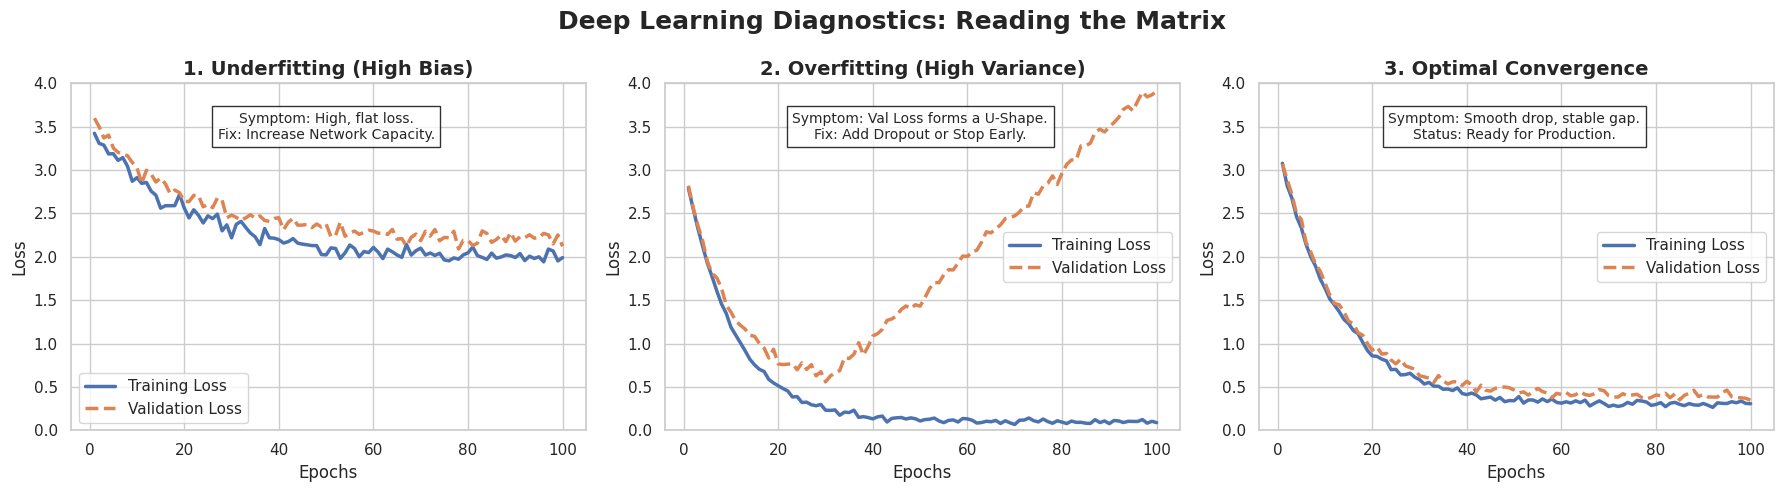

In [4]:
# 1. Simulate the passage of time (100 Epochs)
epochs = np.arange(1, 101)

# 2. Simulate UNDERFITTING (Too simple)
# Both train and val loss start high and barely drop.
train_underfit = 2.0 + np.exp(-epochs * 0.05) * 1.5 + np.random.normal(0, 0.05, 100)
val_underfit   = 2.2 + np.exp(-epochs * 0.05) * 1.4 + np.random.normal(0, 0.05, 100)

# 3. Simulate OVERFITTING (Too complex / Memorization)
# Train loss goes perfectly to 0. Val loss drops, then spikes (U-Shape).
train_overfit = 0.1 + np.exp(-epochs * 0.1) * 3.0 + np.random.normal(0, 0.02, 100)
# Validation spikes after epoch 30 due to memorization of noise
val_overfit   = 0.5 + np.exp(-epochs * 0.1) * 2.5 + (epochs > 30) * ((epochs - 30) * 0.05) + np.random.normal(0, 0.05, 100)

# 4. Simulate OPTIMAL CONVERGENCE (Just right)
# Both drop smoothly and stabilize with a tiny, healthy gap.
train_optimal = 0.3 + np.exp(-epochs * 0.08) * 3.0 + np.random.normal(0, 0.02, 100)
val_optimal   = 0.4 + np.exp(-epochs * 0.08) * 2.9 + np.random.normal(0, 0.03, 100)

# 5. Matplotlib Dashboard Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Deep Learning Diagnostics: Reading the Matrix", fontsize=18, fontweight='bold')

def plot_learning_curve(ax, train_loss, val_loss, title, insight):
    ax.plot(epochs, train_loss, label='Training Loss', linewidth=2.5)
    ax.plot(epochs, val_loss, label='Validation Loss', linewidth=2.5, linestyle='--')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.set_ylim(0, 4)
    ax.legend()
    ax.text(50, 3.5, insight, ha='center', va='center', fontsize=10, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plot_learning_curve(axes[0], train_underfit, val_underfit, 
                    "1. Underfitting (High Bias)", 
                    "Symptom: High, flat loss.\nFix: Increase Network Capacity.")

plot_learning_curve(axes[1], train_overfit, val_overfit, 
                    "2. Overfitting (High Variance)", 
                    "Symptom: Val Loss forms a U-Shape.\nFix: Add Dropout or Stop Early.")

plot_learning_curve(axes[2], train_optimal, val_optimal, 
                    "3. Optimal Convergence", 
                    "Symptom: Smooth drop, stable gap.\nStatus: Ready for Production.")

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Deep Learning Diagnostics like **A Student Studying for the Bar Exam**:

* **The Training Loss (The Practice Tests)**: The student has a book of 500 practice questions. They take the practice test over and over again.
* **The Validation Loss (The Actual Exam)**: A set of highly guarded questions the student has never seen before.
* **Underfitting (The Slacker)**: The student barely studies. They score 30% on the practice test, and 30% on the real exam. They simply lack the "capacity" to understand the law.
* **Overfitting (The Memorizer)**: The student studies the 500 practice questions obsessively. Instead of learning the principles of law, they just memorize the letter of the answer key ("Question 43 is always B"). They score a perfect 100% on the practice test (Training Loss = 0). But when they sit for the real exam, the names in the questions are slightly changed. Because they didn't learn the *logic*, they completely fail the real exam (Validation Loss explodes).
* **Optimal Convergence (The Scholar)**: The student studies the practice questions to learn the *underlying logic* of the law. They score 90% on the practice tests, and because they actually understand the principles, they score 88% on the real, unseen exam.